# AI-Based Spark Job Performance Optimization System

This notebook trains a machine-learning model on simulated PySpark job execution
metrics (record count, partitions, data skew, caching) to **predict job execution
time** and **recommend optimal Spark configurations** (executor memory, cores,
partitions, caching) for a given workload profile.

**Pipeline:**  PySpark micro-benchmarks → EDA → model comparison
(Linear / ElasticNet / RandomForest / GradientBoosting / XGBoost) → XGBoost
hyperparameter tuning → AI recommendation engine → default-vs-optimized comparison
→ results dashboard.

See `README.md` for setup, dataset, and results.
### Author - Abhimanyu Saklani

## 1. Setup

In [37]:
!pip install pyspark scikit-learn pandas numpy matplotlib seaborn joblib optuna -q

In [5]:
import os, time, json, warnings, random,glob
from collections import defaultdict
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings("ignore")

from pyspark.sql            import SparkSession
from pyspark.sql.functions  import col, rand, when
from pyspark.sql.types      import StructType, StructField, IntegerType, DoubleType

from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model    import LinearRegression, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline        import Pipeline
from xgboost                 import XGBRegressor
import joblib

In [6]:
random.seed(42)
np.random.seed(42)

## 2. Spark Session

In [9]:
import os
import sys
from pyspark.sql import SparkSession

PYTHON_PATH = sys.executable
os.environ["PYSPARK_PYTHON"] = PYTHON_PATH
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_PATH
os.environ["SPARK_EVENTLOG_ENABLED"] = "false"
os.makedirs(os.path.join("tmp", "spark-events"), exist_ok=True)

In [35]:
def create_spark_session(executor_memory="2g", cores=2, partitions=100):

    spark = (
        SparkSession.builder
        .appName("AI_Spark_Optimizer")
        .master("local[*]")
        .config("spark.executor.memory", executor_memory)
        .config("spark.executor.cores", str(cores))
        .config("spark.sql.shuffle.partitions", str(partitions))
        .config("spark.driver.memory", "2g")
        .getOrCreate()
    )

    spark.sparkContext.setLogLevel("ERROR")
    return spark


spark = create_spark_session()

print(spark.version)

4.1.1


## 3. Load Dataset

Place `Spark_realtime_metrices.csv` in the `data/` folder at the project root (see `data/README.md`).

In [39]:
print("Retriveing Spark execution dataset …")
df = pd.read_csv("../data/Spark_realtime_metrices.csv")
df.head()

Retriveing Spark execution dataset …


,num_records,cores,executor_memory_gb,partitions,partition_efficiency,skewness,joins,cache_enabled,group_cardinality,num_aggregations,has_orderby,filter_selectivity,data_size_gb,shuffle_size_mb,shuffle_intensity,memory_pressure,execution_time
0,10000000,1,2,3,3.0,0.189065,3,1,1000,2,0,0.77,0.9313,1500.0,2.7940,0.4657,2.0089
1,100000,1,2,4,4.0,0.328867,1,1,100,4,1,0.73,0.0093,5.0,0.0093,0.0047,0.8231
2,3000000,1,2,3,3.0,0.516016,3,0,20000,2,1,0.32,0.2794,450.0,0.8382,0.1397,1.8777
3,1000000,1,2,4,4.0,0.434153,2,0,5000,1,0,0.64,0.0931,100.0,0.1863,0.0466,1.5456
4,100000,1,2,6,6.0,0.419996,3,0,1000,1,0,0.35,0.0093,15.0,0.0279,0.0047,1.8126


In [41]:
print(f"Dataset shape : {df.shape}")
print(df.describe().round(2))

Dataset shape : (4000, 17)
       num_records    cores  executor_memory_gb  partitions  \
count      4000.00  4000.00             4000.00     4000.00   
mean    5439200.00     3.25                5.00       12.68   
std     6790828.54     1.92                2.24        9.16   
min      100000.00     1.00                2.00        2.00   
25%      500000.00     1.75                3.50        5.00   
50%     3000000.00     3.00                5.00       10.00   
75%     5000000.00     4.50                6.50       18.00   
max    20000000.00     6.00                8.00       36.00   

       partition_efficiency  skewness    joins  cache_enabled  \
count                4000.0   4000.00  4000.00        4000.00   
mean                    3.9      0.48     2.09           0.53   
std                     1.4      0.22     0.82           0.50   
min                     2.0      0.10     1.00           0.00   
25%                     3.0      0.29     1.00           0.00   
50%            

# 4. Data Validation

In [44]:
def validate_dataset(df):
    print("Missing values per column:")
    print(df.isna().sum())

    n_dupes = df.duplicated().sum()
    print(f"\nDuplicate rows: {n_dupes}")

    invalid = df[
        (df["execution_time"] <= 0) |
        (df["num_records"] <= 0) |
        (df["partitions"] <= 0) |
        (df["skewness"] < 0) | (df["skewness"] > 1) |
        (df["filter_selectivity"] < 0) | (df["filter_selectivity"] > 1)
    ]
    print(f"Invalid rows (non-physical values): {len(invalid)}")

    print("\nHardware config coverage:")
    print(df.groupby(["cores", "executor_memory_gb"]).size())

    print("\nWorkload coverage:")
    for c in ["joins", "num_aggregations", "has_orderby", "cache_enabled"]:
        print(f"  {c:<20}: {sorted(df[c].unique())}")

    df_clean = df.drop_duplicates()
    df_clean = df_clean[
        (df_clean["execution_time"] > 0) &
        (df_clean["num_records"] > 0) &
        (df_clean["partitions"] > 0) &
        (df_clean["skewness"].between(0, 1)) &
        (df_clean["filter_selectivity"].between(0, 1))
    ].reset_index(drop=True)

    print(f"\nRows before cleaning: {len(df)}  ->  after cleaning: {len(df_clean)}")
    return df_clean


df = validate_dataset(df)

Missing values per column:
num_records             0
cores                   0
executor_memory_gb      0
partitions              0
partition_efficiency    0
skewness                0
joins                   0
cache_enabled           0
group_cardinality       0
num_aggregations        0
has_orderby             0
filter_selectivity      0
data_size_gb            0
shuffle_size_mb         0
shuffle_intensity       0
memory_pressure         0
execution_time          0
dtype: int64

Duplicate rows: 0
Invalid rows (non-physical values): 0

Hardware config coverage:
cores  executor_memory_gb
1      2                     250
       4                     250
       6                     250
       8                     250
2      2                     250
       4                     250
       6                     250
       8                     250
4      2                     250
       4                     250
       6                     250
       8                     250
6      2    

In [21]:
print(
    pd.DataFrame({
        "Column": df.columns,
        "Dtype": df.dtypes.astype(str),
        "Missing": df.isna().sum().values,
        "Unique": df.nunique().values
    })
)

                                    Column    Dtype  Missing  Unique
num_records                    num_records    int64        0       7
cores                                cores    int64        0       4
executor_memory_gb      executor_memory_gb    int64        0       4
partitions                      partitions    int64        0      14
partition_efficiency  partition_efficiency  float64        0       5
skewness                          skewness  float64        0     250
joins                                joins    int64        0       3
cache_enabled                cache_enabled    int64        0       2
group_cardinality        group_cardinality    int64        0       4
num_aggregations          num_aggregations    int64        0       4
has_orderby                    has_orderby    int64        0       2
filter_selectivity      filter_selectivity  float64        0      70
data_size_gb                  data_size_gb  float64        0       7
shuffle_size_mb            shuffle

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_records           4000 non-null   int64  
 1   cores                 4000 non-null   int64  
 2   executor_memory_gb    4000 non-null   int64  
 3   partitions            4000 non-null   int64  
 4   partition_efficiency  4000 non-null   float64
 5   skewness              4000 non-null   float64
 6   joins                 4000 non-null   int64  
 7   cache_enabled         4000 non-null   int64  
 8   group_cardinality     4000 non-null   int64  
 9   num_aggregations      4000 non-null   int64  
 10  has_orderby           4000 non-null   int64  
 11  filter_selectivity    4000 non-null   float64
 12  data_size_gb          4000 non-null   float64
 13  shuffle_size_mb       4000 non-null   float64
 14  shuffle_intensity     4000 non-null   float64
 15  memory_pressure      

# 5. EDA

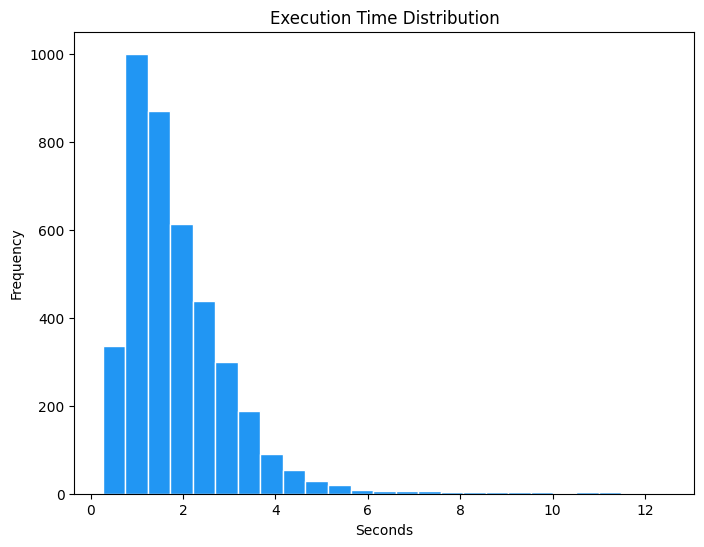

In [53]:
# Plot 1: Execution Time Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_raw["execution_time"], bins=25, color="#2196F3", edgecolor="white")
plt.title("Execution Time Distribution")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

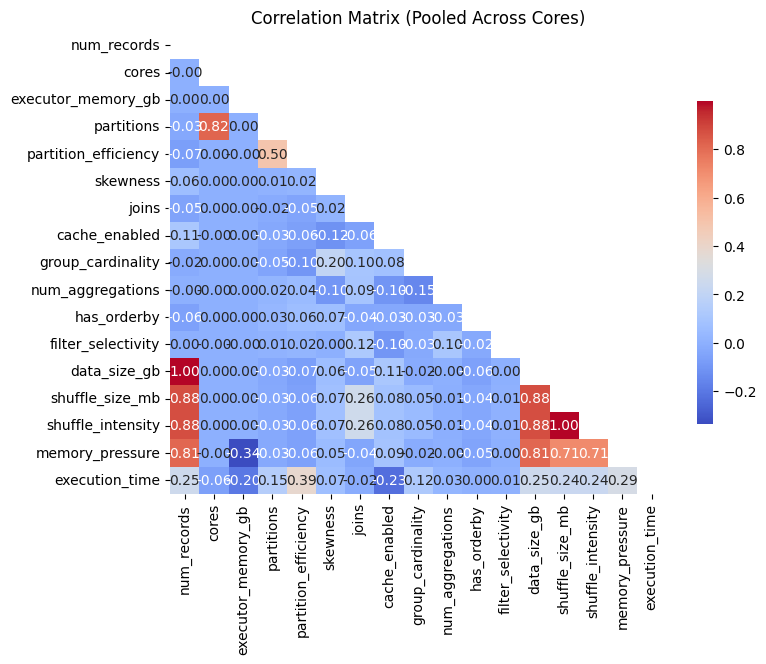

In [51]:
# Plot 2: Correlation Matrix
plt.figure(figsize=(8, 6))
corr = df_raw.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.7})
plt.title("Correlation Matrix (Pooled Across Cores)")
plt.show()

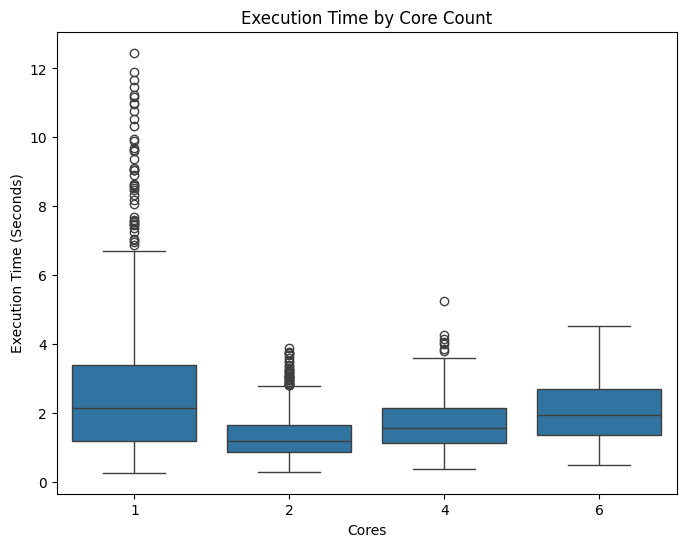

In [57]:
# Plot 3: Execution Time by Core Count
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_raw, x="cores", y="execution_time")
plt.title("Execution Time by Core Count")
plt.xlabel("Cores")
plt.ylabel("Execution Time (Seconds)")
plt.show()

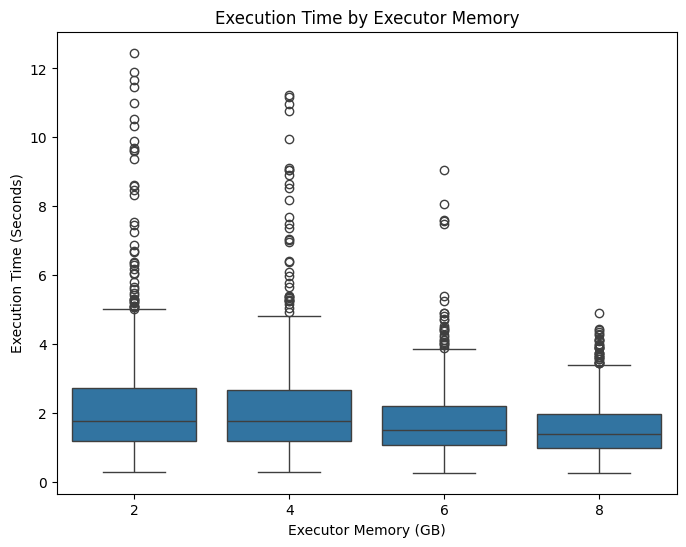

In [61]:
# Plot 4: Execution Time by Executor Memory
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_raw, x="executor_memory_gb", y="execution_time")
plt.title("Execution Time by Executor Memory")
plt.xlabel("Executor Memory (GB)")
plt.ylabel("Execution Time (Seconds)")
plt.show()

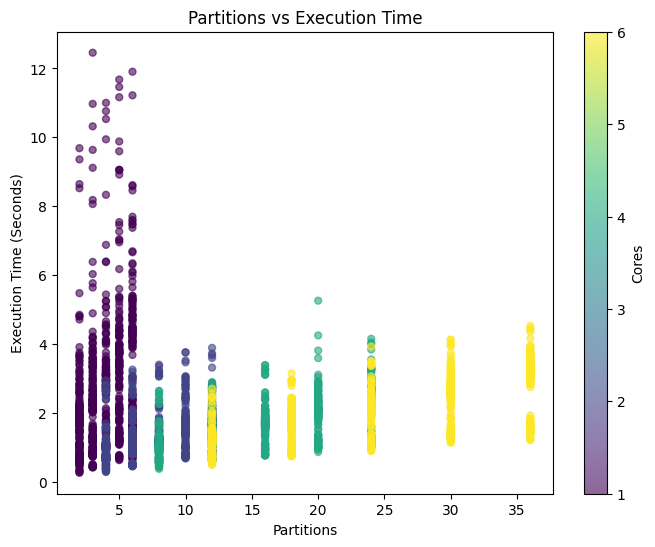

In [65]:
# Plot 5: Partitions vs Execution Time
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df_raw["partitions"],
    df_raw["execution_time"],
    c=df_raw["cores"],
    cmap="viridis",
    alpha=0.6,
    s=25
)
plt.colorbar(sc, label="Cores")
plt.title("Partitions vs Execution Time")
plt.xlabel("Partitions")
plt.ylabel("Execution Time (Seconds)")
plt.show()

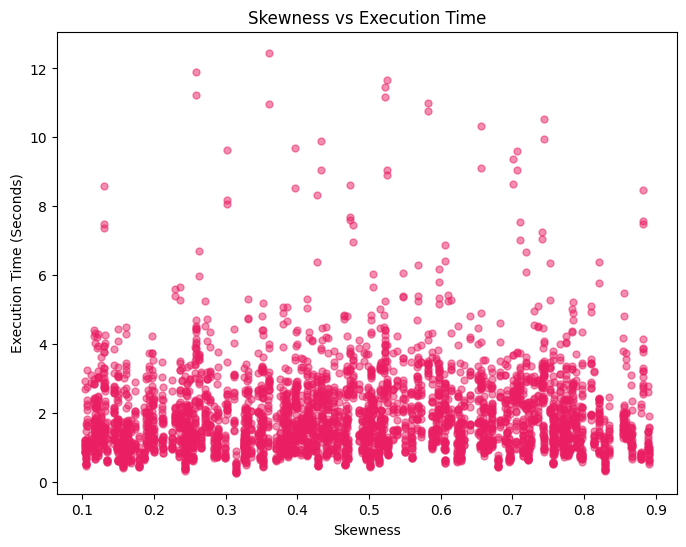

In [69]:
# Plot 6: Skewness vs Execution Time
plt.figure(figsize=(8, 6))
plt.scatter(
    df_raw["skewness"],
    df_raw["execution_time"],
    color="#E91E63",
    alpha=0.5,
    s=25
)
plt.title("Skewness vs Execution Time")
plt.xlabel("Skewness")
plt.ylabel("Execution Time (Seconds)")
plt.show()

In [73]:
def correlation_by_cores(df):
    """
    Calculate Pearson correlations with execution_time
    separately for each core configuration.
    """
    correlations = {}

    for core in sorted(df["cores"].unique()):
        core_df = df[df["cores"] == core]

        correlations[core] = (
            core_df
            .select_dtypes(include="number")
            .corr()["execution_time"]
            .sort_values(ascending=False)
        )

    return correlations

In [75]:
corr_by_cores = correlation_by_cores(df_raw)

for core, corr_series in corr_by_cores.items():
    print(f"\n{'=' * 50}")
    print(f"CORES = {core}")
    print(f"{'=' * 50}")
    print(corr_series)


CORES = 1
execution_time          1.000000
memory_pressure         0.540082
data_size_gb            0.385278
num_records             0.385277
shuffle_size_mb         0.354616
shuffle_intensity       0.354616
partitions              0.296328
partition_efficiency    0.296328
group_cardinality       0.091931
skewness                0.083092
num_aggregations        0.054749
filter_selectivity      0.033275
has_orderby             0.001994
joins                  -0.012330
cache_enabled          -0.290483
executor_memory_gb     -0.515567
cores                        NaN
Name: execution_time, dtype: float64

CORES = 2
execution_time          1.000000
partitions              0.510423
partition_efficiency    0.510423
data_size_gb            0.418732
num_records             0.418732
shuffle_size_mb         0.392100
shuffle_intensity       0.392099
memory_pressure         0.328162
group_cardinality       0.189155
skewness                0.099239
num_aggregations        0.036595
executor_memory_g

## 6 · Feature Engineering

Two things happen here: a **collinearity check** (via each feature's
variance inflation factor, computed with plain linear regression so no extra
dependency is needed) and a **data-driven feature selection** — candidate
engineered features are proposed, then kept or dropped based on an ablation
study rather than intuition alone.

`partition_efficiency = partitions / cores` is collinear with its own two
inputs by construction, which the VIF check below should surface directly.


In [81]:
def variance_inflation_factors(df, columns):
    """VIF_i = 1 / (1 - R2_i), where R2_i comes from regressing feature i
    on all the other columns. VIF > 5-10 signals problematic collinearity."""
    vifs = {}
    for col in columns:
        others = [c for c in columns if c != col]
        lr = LinearRegression()
        lr.fit(df[others].values, df[col].values)
        r2 = lr.score(df[others].values, df[col].values)
        vifs[col] = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

FEATURES = df.select_dtypes(include="number").columns.drop("execution_time").tolist()
vif_series = variance_inflation_factors(df_raw, FEATURES)
print("Variance Inflation Factors (higher = more collinear with the rest):")
print(vif_series.round(2))

Variance Inflation Factors (higher = more collinear with the rest):
num_records               inf
data_size_gb              inf
shuffle_size_mb           inf
shuffle_intensity         inf
partitions              11.65
cores                    8.78
memory_pressure          4.45
partition_efficiency     3.90
joins                    1.82
executor_memory_gb       1.51
skewness                 1.12
group_cardinality        1.11
num_aggregations         1.08
cache_enabled            1.07
filter_selectivity       1.04
has_orderby              1.02
dtype: float64


In [83]:
def engineer_features(df):
    df = df.copy()
    df["records_per_partition"] = df["num_records"] / df["partitions"]
    df["join_load"] = df["joins"] * df["group_cardinality"]
    df["agg_complexity"] = df["num_aggregations"] * (1 + df["has_orderby"])
    df["skew_joins_interaction"] = df["skewness"] * df["joins"]
    df["log_num_records"] = np.log1p(df["num_records"])
    return df


df_engineered = engineer_features(df_raw)

ENGINEERED_FEATURE_NAMES = [
    "records_per_partition", "join_load", "agg_complexity",
    "skew_joins_interaction", "log_num_records",
]
CANDIDATE_FEATURES = FEATURES + ENGINEERED_FEATURE_NAMES
print(f"Candidate feature set: {len(FEATURES)} raw + {len(ENGINEERED_FEATURE_NAMES)} "
      f"engineered = {len(CANDIDATE_FEATURES)} total")

Candidate feature set: 16 raw + 5 engineered = 21 total
